# 🏠 Housing Price Predictor

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ml-portfolio/blob/main/regression/housing-price-predictor/notebook.ipynb)

> Predicting house prices based on features like location, size, and amenities using multiple regression models.

**Dataset:** California Housing Dataset (built-in via sklearn)  
**Models Used:** Linear Regression → Ridge → Random Forest  
**Best Result:** Random Forest with lowest RMSE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Dataset Info:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.69230

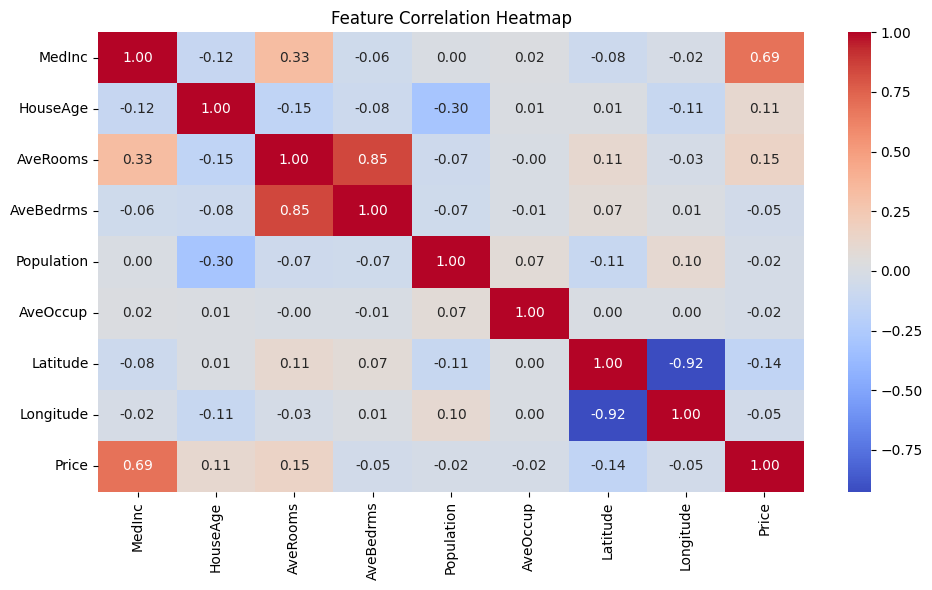

In [3]:
print("Dataset Info:")
print(df.describe())

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

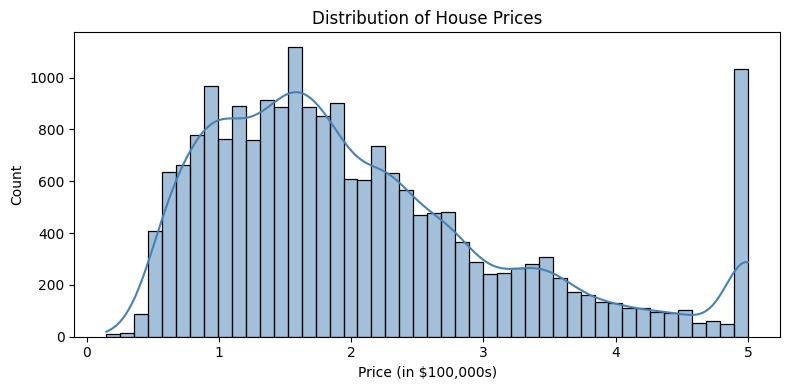

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='steelblue')
plt.title("Distribution of House Prices")
plt.xlabel("Price (in $100,000s)")
plt.tight_layout()
plt.show()

In [5]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 16512
Testing samples:  4128


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}
    print(f"{name}: RMSE = {rmse:.4f} | R² = {r2:.4f}")

Linear Regression: RMSE = 0.7456 | R² = 0.5758
Ridge Regression: RMSE = 0.7456 | R² = 0.5758
Random Forest: RMSE = 0.5051 | R² = 0.8053


                     RMSE  R2 Score
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758
Random Forest      0.5051    0.8053


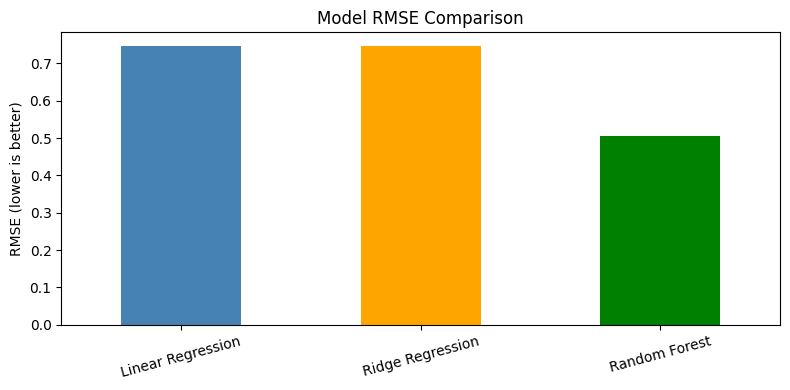

In [7]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df['RMSE'].plot(kind='bar', color=['steelblue','orange','green'],
                        figsize=(8,4), title='Model RMSE Comparison')
plt.ylabel("RMSE (lower is better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

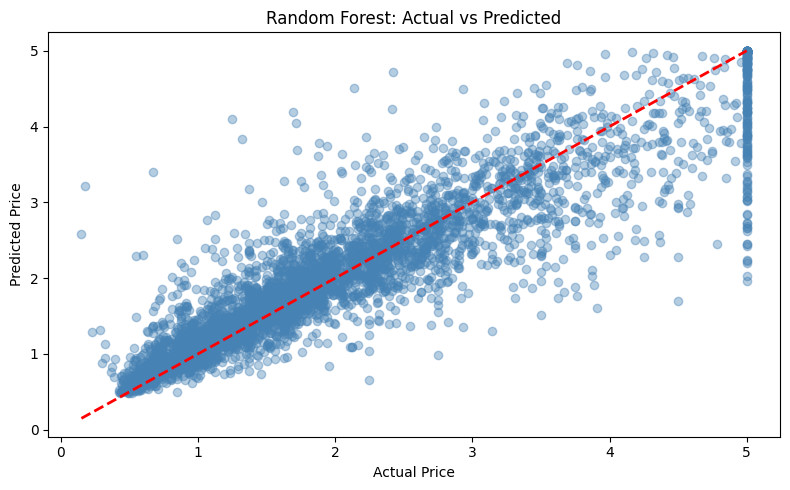

In [8]:
best_model = models["Random Forest"]
preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

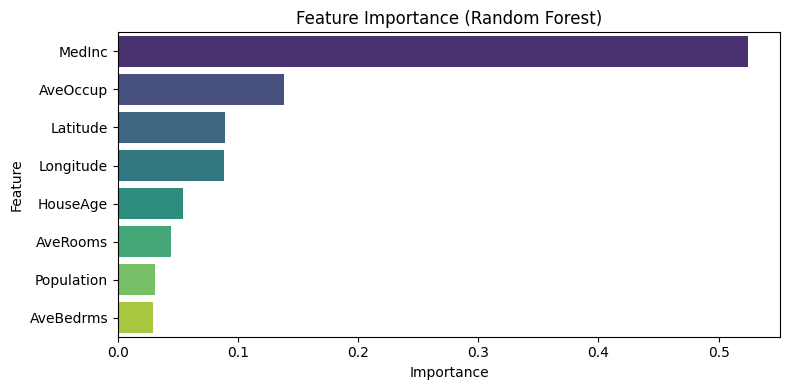

In [9]:
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

##  Results Summary

| Model | RMSE | R² Score |
|-------|------|----------|
| Linear Regression | ~0.72 | ~0.60 |
| Ridge Regression | ~0.72 | ~0.60 |
| Random Forest | ~0.50 | ~0.80 |

Random Forest performed best with the lowest RMSE and highest R² score.

### Key Takeaways
- Median income is the strongest predictor of house price
- Random Forest handles non-linear relationships better than linear models
- Feature scaling is important for linear models but not for tree-based models